In [1]:
#import sys
#!"{sys.executable}" -m pip uninstall -y tensorflow tensorflow-gpu
#!"{sys.executable}" -m pip install "tensorflow<2.11"
#!"{sys.executable}" -m pip install xgboost
#!"{sys.executable}" -m pip install catboost
#!"{sys.executable}" -m pip install "numpy<2.0" "mendeleev<1.0.0" --force-reinstall

In [2]:
import re
import time
import requests
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from mendeleev import element
import matplotlib.pyplot as plt
from pymatgen.core import Composition
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from matminer.featurizers.composition import ElementProperty
pd.set_option('display.float_format', '{:.4f}'.format)
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.10.1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


C:\Program Files\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
import json
import joblib

ARTIFACT_DIR = "model"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

saved_keras_items = []
saved_xgb_models = {}

In [4]:
# =========================
# FEATURE ENGINEERING ДЛЯ df_aflow
# UNIVERSAL MULTI-OUTPUT VERSION
# Можно менять target_cols без переписывания остального кода
# =========================

import re
import warnings
import numpy as np
import pandas as pd

from mendeleev import element
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings(
    "ignore",
    message=".*has multiple allotropes.*",
    category=UserWarning
)

# =========================
# 0. LOAD DATA
# =========================

df_aflow = pd.read_csv("aflow_agl.csv")

# =========================
# 1. SETTINGS
# =========================

target_cols = [
    "agl_debye",
    "agl_heat_capacity_Cv_300K",
    "agl_heat_capacity_Cp_300K",
    "agl_thermal_conductivity_300K",
    "agl_thermal_expansion_300K",
    "agl_bulk_modulus_isothermal_300K",
    "agl_bulk_modulus_static_300K",
    "agl_acoustic_debye",
    "agl_gruneisen",
]

agl_cols = [
    "agl_debye",
    "agl_acoustic_debye",
    "agl_gruneisen",
    "agl_heat_capacity_Cp_300K",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_conductivity_300K",
    "agl_thermal_expansion_300K",
    "agl_bulk_modulus_isothermal_300K",
    "agl_bulk_modulus_static_300K",
]

# Правила чистки таргетов.
# Если target отсутствует в словаре, он только проверяется на notna().
target_clean_rules = {
    "agl_debye": {"min": -1000, "max": 2500},
    "agl_acoustic_debye": {"min": -1000, "max": 2500},
    "agl_heat_capacity_Cp_300K": {"min": -1000},
    "agl_heat_capacity_Cv_300K": {"min": -1000},
    "agl_thermal_conductivity_300K": {"min": -1000},
    "agl_bulk_modulus_isothermal_300K": {"min": -1000},
    "agl_bulk_modulus_static_300K": {"min": -1000},

    # Эти признаки не фильтруем по min=0, потому что могут быть около нуля/отрицательными.
    # "agl_gruneisen": {},
    # "agl_thermal_expansion_300K": {},
}

technical_cols = [
    "Unnamed: 0",
    "index",
    "row_id",
    "source",
    "original_index",
]

remove_as_duplicates_or_weak = [
    "atoms_per_cell_volume",
    "atomic_weight_mean_unw",
    "Z_mean_unw",
    "atomic_radius_mean_unw",
    "period_mean_unw",
    "period_mean_w",
    "covalent_radius_mean_unw",
    "atomic_weight_div_density",
    "log_density",
    "volume_atom",
    "MagpieData mean AtomicWeight",
    "MagpieData mean AtomicRadius",
    "MagpieData mean Row",
    "MagpieData mean Electronegativity",
    "inv_volume_atom",
]

old_feature_prefixes = [
    "comp_",
    "formula_",
    "stoich_",
    "el_",
    "Z_",
    "atomic_weight_",
    "period_",
    "en_pauling_",
    "atomic_radius_",
    "covalent_radius_",
    "melting_point_",
    "ionization_energy_",
    "specific_heat_",
    "density_",
    "energy_",
    "enthalpy_",
    "volume_",
    "log_",
    "inv_",
    "sqrt_",
    "radius_",
    "mass_",
    "packing_",
]

protected_cols = set([
    "compound",
    "volume_atom",
    "volume_cell",
    "density",
    "energy_atom",
    "enthalpy_formation_atom",
    "Egap",
    "Egap_type",
    "natoms",
    "nspecies",
    "spacegroup_relax",
] + agl_cols)

# =========================
# 2. BASIC CLEANING
# =========================

df_fe = df_aflow.copy()

missing_targets = [c for c in target_cols if c not in df_fe.columns]
if len(missing_targets) > 0:
    raise ValueError(f"Нет target-столбцов в df_aflow: {missing_targets}")

cols_to_remove = []

for col in df_fe.columns:
    if any(col.startswith(prefix) for prefix in old_feature_prefixes):
        if col not in protected_cols:
            cols_to_remove.append(col)

df_fe = df_fe.drop(columns=cols_to_remove, errors="ignore")
df_fe = df_fe.drop(columns=technical_cols, errors="ignore")

# Для multi-output оставляем только строки, где известны все target_cols
df_fe = df_fe.dropna(subset=target_cols)

# Универсальная чистка target_cols
for col in target_cols:
    df_fe[col] = pd.to_numeric(df_fe[col], errors="coerce")
    df_fe = df_fe[df_fe[col].notna()]

    rules = target_clean_rules.get(col, {})

    if "min" in rules:
        df_fe = df_fe[df_fe[col] > rules["min"]]

    if "max" in rules:
        df_fe = df_fe[df_fe[col] < rules["max"]]

# Если нужно строго только сплавы, раскомментируй:
# df_fe = df_fe[df_fe["nspecies"] >= 2]

# Если нужно строго только металлы, раскомментируй:
# df_fe = df_fe[
#     (pd.to_numeric(df_fe["Egap"], errors="coerce").fillna(0) <= 0.1) |
#     (df_fe["Egap_type"].astype(str).str.lower() == "metal")
# ]

df_fe = df_fe.reset_index(drop=True)

# =========================
# 3. FORMULA PARSER
# =========================

def parse_formula(formula):
    if pd.isna(formula):
        return {}

    formula = str(formula).strip().replace(" ", "")
    parts = re.findall(r"([A-Z][a-z]?)([0-9]*\.?[0-9]*)", formula)

    comp = {}

    for el, amount in parts:
        amount = float(amount) if amount != "" else 1.0
        comp[el] = comp.get(el, 0.0) + amount

    return comp

# =========================
# 4. ELEMENT PROPERTIES FROM MENDELEEV
# =========================

_element_cache = {}

def safe_float(x):
    try:
        if x is None:
            return np.nan
        return float(x)
    except Exception:
        return np.nan

def get_element_props(symbol):
    if symbol in _element_cache:
        return _element_cache[symbol]

    try:
        el = element(symbol)

        props = {
            "Z": safe_float(getattr(el, "atomic_number", np.nan)),
            "atomic_weight": safe_float(getattr(el, "atomic_weight", np.nan)),
            "period": safe_float(getattr(el, "period", np.nan)),
            "en_pauling": safe_float(getattr(el, "en_pauling", np.nan)),
            "atomic_radius": safe_float(getattr(el, "atomic_radius", np.nan)),
            "covalent_radius": safe_float(getattr(el, "covalent_radius_pyykko", np.nan)),
            "melting_point": safe_float(getattr(el, "melting_point", np.nan)),
            "specific_heat": safe_float(getattr(el, "specific_heat", np.nan)),
        }

        try:
            props["ionization_energy"] = safe_float(el.ionenergies.get(1, np.nan))
        except Exception:
            props["ionization_energy"] = np.nan

    except Exception as e:
        print("MENDELEEV ERROR:", symbol, repr(e))

        props = {
            "Z": np.nan,
            "atomic_weight": np.nan,
            "period": np.nan,
            "en_pauling": np.nan,
            "atomic_radius": np.nan,
            "covalent_radius": np.nan,
            "melting_point": np.nan,
            "specific_heat": np.nan,
            "ionization_energy": np.nan,
        }

    _element_cache[symbol] = props
    return props

# =========================
# 5. COMPOSITION FEATURES
# =========================

def weighted_avg_abs_dev(vals, weights, mean):
    return np.sum(weights * np.abs(vals - mean))

def composition_features(formula):
    comp = parse_formula(formula)

    if len(comp) == 0:
        return {}

    elements = list(comp.keys())
    amounts = np.array(list(comp.values()), dtype=float)

    total_atoms = amounts.sum()
    fractions = amounts / (total_atoms + 1e-12)

    feats = {}

    feats["comp_n_elements"] = len(elements)
    feats["comp_total_atoms"] = total_atoms
    feats["comp_max_fraction"] = fractions.max()
    feats["comp_fraction_l2"] = np.sqrt(np.sum(fractions ** 2))
    feats["comp_config_entropy"] = -np.sum(fractions * np.log(fractions + 1e-12))

    prop_names = [
        "Z",
        "atomic_weight",
        "period",
        "en_pauling",
        "atomic_radius",
        "covalent_radius",
        "melting_point",
        "specific_heat",
        "ionization_energy",
    ]

    prop_values = {p: [] for p in prop_names}

    for el_symbol in elements:
        props = get_element_props(el_symbol)

        for p in prop_names:
            prop_values[p].append(props[p])

    for p in prop_names:
        vals = np.array(prop_values[p], dtype=float)
        valid = ~np.isnan(vals)

        if valid.sum() == 0:
            feats[f"{p}_mean_w"] = np.nan
            feats[f"{p}_min"] = np.nan
            feats[f"{p}_max"] = np.nan
            feats[f"{p}_range"] = np.nan
            feats[f"{p}_std_w"] = np.nan
            feats[f"{p}_avg_abs_dev_w"] = np.nan
            continue

        vals_valid = vals[valid]
        fr_valid = fractions[valid]
        fr_valid = fr_valid / (fr_valid.sum() + 1e-12)

        mean_w = np.sum(vals_valid * fr_valid)
        var_w = np.sum(fr_valid * (vals_valid - mean_w) ** 2)

        feats[f"{p}_mean_w"] = mean_w
        feats[f"{p}_min"] = vals_valid.min()
        feats[f"{p}_max"] = vals_valid.max()
        feats[f"{p}_range"] = vals_valid.max() - vals_valid.min()
        feats[f"{p}_std_w"] = np.sqrt(var_w)
        feats[f"{p}_avg_abs_dev_w"] = weighted_avg_abs_dev(vals_valid, fr_valid, mean_w)

    return feats

comp_feat_df = pd.DataFrame(
    df_fe["compound"].apply(composition_features).tolist(),
    index=df_fe.index
)

df_fe = pd.concat([df_fe, comp_feat_df], axis=1)

# =========================
# 6. ELEMENT FRACTION FEATURES
# =========================

all_elements = set()

for formula in df_fe["compound"]:
    all_elements.update(parse_formula(formula).keys())

all_elements = sorted(all_elements)

element_fraction_rows = []

for formula in df_fe["compound"]:
    comp = parse_formula(formula)
    row = {f"el_{el}": 0.0 for el in all_elements}

    if len(comp) > 0:
        total = sum(comp.values())

        for el, amount in comp.items():
            row[f"el_{el}"] = amount / (total + 1e-12)

    element_fraction_rows.append(row)

element_fraction_df = pd.DataFrame(element_fraction_rows, index=df_fe.index)
df_fe = pd.concat([df_fe, element_fraction_df], axis=1)

# =========================
# 7. PHYSICAL / INTERACTION FEATURES
# =========================

eps = 1e-9

def add_if_cols_exist(new_col, cols, func):
    if set(cols).issubset(df_fe.columns):
        try:
            df_fe[new_col] = func(df_fe)
        except Exception as e:
            print("Feature error:", new_col, repr(e))
            df_fe[new_col] = np.nan

add_if_cols_exist("inv_volume_atom", ["volume_atom"], lambda d: 1.0 / (d["volume_atom"] + eps))
add_if_cols_exist("log_volume_atom", ["volume_atom"], lambda d: np.log1p(d["volume_atom"].clip(lower=0)))
add_if_cols_exist("volume_atom_pow_minus_1_3", ["volume_atom"], lambda d: 1.0 / np.power(d["volume_atom"] + eps, 1.0 / 3.0))
add_if_cols_exist("volume_atom_pow_minus_2_3", ["volume_atom"], lambda d: 1.0 / np.power(d["volume_atom"] + eps, 2.0 / 3.0))
add_if_cols_exist("inv_density", ["density"], lambda d: 1.0 / (d["density"] + eps))

add_if_cols_exist("abs_energy_atom", ["energy_atom"], lambda d: d["energy_atom"].abs())
add_if_cols_exist("energy_density_proxy", ["energy_atom", "volume_atom"], lambda d: d["energy_atom"].abs() / (d["volume_atom"] + eps))
add_if_cols_exist("energy_density_signed", ["energy_atom", "volume_atom"], lambda d: d["energy_atom"] / (d["volume_atom"] + eps))

add_if_cols_exist("density_div_atomic_weight", ["density", "atomic_weight_mean_w"], lambda d: d["density"] / (d["atomic_weight_mean_w"] + eps))
add_if_cols_exist("Z_div_atomic_weight", ["Z_mean_w", "atomic_weight_mean_w"], lambda d: d["Z_mean_w"] / (d["atomic_weight_mean_w"] + eps))
add_if_cols_exist("radius_div_volume_atom", ["atomic_radius_mean_w", "volume_atom"], lambda d: d["atomic_radius_mean_w"] / (d["volume_atom"] + eps))
add_if_cols_exist("volume_div_radius3", ["volume_atom", "atomic_radius_mean_w"], lambda d: d["volume_atom"] / (np.power(d["atomic_radius_mean_w"], 3) + eps))

add_if_cols_exist("melting_div_atomic_weight", ["melting_point_mean_w", "atomic_weight_mean_w"], lambda d: d["melting_point_mean_w"] / (d["atomic_weight_mean_w"] + eps))

if "Egap" in df_fe.columns:
    df_fe["Egap"] = pd.to_numeric(df_fe["Egap"], errors="coerce")
    df_fe["log_Egap"] = np.log1p(df_fe["Egap"].clip(lower=0))
    df_fe["Egap_is_zero"] = (df_fe["Egap"].fillna(0) <= 1e-6).astype(float)

if "Egap_type" in df_fe.columns:
    egap_type = df_fe["Egap_type"].astype(str).str.lower()
    df_fe["Egap_type_is_metal"] = (egap_type == "metal").astype(float)

if "spacegroup_relax" in df_fe.columns:
    df_fe["spacegroup_relax"] = pd.to_numeric(df_fe["spacegroup_relax"], errors="coerce")


########################################## PROXY
eps = 1e-9
# proxy скорости звука: чем выше "энергетическая жесткость" и ниже плотность, тем выше частоты
df_fe["sound_velocity_proxy"] = np.sqrt(
    df_fe["energy_density_proxy"].clip(lower=0) / (df_fe["density"] + eps)
)
# proxy Debye: скорость звука * обратная характерная длина
df_fe["debye_proxy"] = (
    df_fe["sound_velocity_proxy"] *
    df_fe["volume_atom_pow_minus_1_3"]
)
# относительный разброс масс
df_fe["atomic_weight_rel_range"] = (
    df_fe["atomic_weight_range"] /
    (df_fe["atomic_weight_mean_w"] + eps)
)
# относительный разброс радиусов
df_fe["atomic_radius_rel_range"] = (
    df_fe["atomic_radius_range"] /
    (df_fe["atomic_radius_mean_w"] + eps)
)
# химико-структурные взаимодействия
df_fe["en_radius_interaction"] = (
    df_fe["en_pauling_mean_w"] *
    df_fe["atomic_radius_mean_w"]
)
df_fe["en_Z_interaction"] = (
    df_fe["en_pauling_mean_w"] *
    df_fe["Z_mean_w"]
)
# доля лёгких элементов
light_elements = ["H", "B", "C", "N", "O"]
light_cols = [f"el_{el}" for el in light_elements if f"el_{el}" in df_fe.columns]
if len(light_cols) > 0:
    df_fe["light_element_fraction"] = df_fe[light_cols].sum(axis=1)
else:
    df_fe["light_element_fraction"] = 0.0
########################################## PROXY


# =========================
# 8. FINAL FEATURE SELECTION
# =========================

selected_physical_cols = [
    "density_div_atomic_weight",
    "energy_density_proxy",
    "energy_density_signed",
    "volume_atom_pow_minus_2_3",
    "volume_atom_pow_minus_1_3",
    "log_volume_atom",

    "atomic_weight_mean_w",
    "atomic_weight_range",
    "Z_mean_w",
    "Z_range",
    "Z_div_atomic_weight",
    "atomic_radius_mean_w",
    "atomic_radius_range",
    "covalent_radius_mean_w",

    "en_pauling_mean_w",
    "ionization_energy_mean_w",
    "ionization_energy_min",
    "ionization_energy_max",
    "specific_heat_min",
    "melting_div_atomic_weight",
    "melting_point_mean_w",

    "comp_max_fraction",
    "comp_fraction_l2",
    "comp_config_entropy",

    "density",
    "inv_density",
    "Egap",
    "log_Egap",
    "Egap_is_zero",
    "Egap_type_is_metal",
    "natoms",
    "nspecies",
    "spacegroup_relax",
    "energy_atom",
    "enthalpy_formation_atom",

    "sound_velocity_proxy",
    "debye_proxy",
    "atomic_weight_rel_range",
    "atomic_radius_rel_range",
    "en_radius_interaction",
    "en_Z_interaction",
    "light_element_fraction",
]

element_cols = [c for c in df_fe.columns if c.startswith("el_")]

final_feature_cols = []

for col in selected_physical_cols + element_cols:
    if col in df_fe.columns and col not in final_feature_cols:
        final_feature_cols.append(col)

final_feature_cols = [
    col for col in final_feature_cols
    if col not in remove_as_duplicates_or_weak
]

# Защита от утечки:
# убираем ВСЕ agl_* и ВСЕ target_cols из X
final_feature_cols = [
    col for col in final_feature_cols
    if col not in agl_cols and col not in target_cols
]

# =========================
# 9. FINAL CLEANING
# =========================

df_fe = df_fe.replace([np.inf, -np.inf], np.nan)

final_feature_cols = [
    c for c in final_feature_cols
    if c in df_fe.columns and not df_fe[c].isna().all()
]

final_feature_cols = [
    c for c in final_feature_cols
    if df_fe[c].nunique(dropna=True) > 1
]

X = df_fe[final_feature_cols].copy()
X = X.select_dtypes(include=[np.number])

y = df_fe[target_cols].astype(float)

groups = df_fe["compound"].astype(str)
feature_cols = list(X.columns)

print("Before split:")
print("df_fe shape:", df_fe.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Targets:", target_cols)
print("Feature count:", len(feature_cols))
print("Non-element feature count:", len([c for c in feature_cols if not c.startswith("el_")]))
print("Element feature count:", len([c for c in feature_cols if c.startswith("el_")]))

print("\nRemoved duplicate/weak columns if present:")
print([c for c in remove_as_duplicates_or_weak if c in df_fe.columns])

print("\nTarget NaN check:")
print(y.isna().sum())

print("\nAGL leakage check:")
print([c for c in X.columns if c in agl_cols or c in target_cols])

# =========================
# 10. GROUP TRAIN / VAL SPLIT
# =========================

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_val = X.iloc[val_idx].copy()

y_train = y.iloc[train_idx].copy()
y_val = y.iloc[val_idx].copy()

id_train = df_fe.iloc[train_idx].index
id_val = df_fe.iloc[val_idx].index

compound_train = df_fe.iloc[train_idx]["compound"].values
compound_val = df_fe.iloc[val_idx]["compound"].values

# =========================
# 11. IMPUTER + SCALER FOR X
# =========================

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)

# =========================
# 12. SCALER FOR MULTI-OUTPUT y
# =========================

y_mean = y_train.mean()
y_std = y_train.std()
y_std = y_std.replace(0, 1.0)

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled = (y_val - y_mean) / y_std

y_train_scaled_np = y_train_scaled.values.astype(np.float32)
y_val_scaled_np = y_val_scaled.values.astype(np.float32)

print("\nAfter split:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_train_imp:", X_train_imp.shape)
print("X_val_imp:", X_val_imp.shape)
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_train_scaled_np:", y_train_scaled_np.shape)
print("y_val_scaled_np:", y_val_scaled_np.shape)

print("\nNaN check:")
print("X_train_scaled NaN:", np.isnan(X_train_scaled).sum())
print("X_val_scaled NaN:", np.isnan(X_val_scaled).sum())
print("y_train_scaled_np NaN:", np.isnan(y_train_scaled_np).sum())
print("y_val_scaled_np NaN:", np.isnan(y_val_scaled_np).sum())

print("\nSelected non-element features:")
print([c for c in feature_cols if not c.startswith("el_")])

Before split:
df_fe shape: (5653, 188)
X shape: (5653, 127)
y shape: (5653, 9)
Targets: ['agl_debye', 'agl_heat_capacity_Cv_300K', 'agl_heat_capacity_Cp_300K', 'agl_thermal_conductivity_300K', 'agl_thermal_expansion_300K', 'agl_bulk_modulus_isothermal_300K', 'agl_bulk_modulus_static_300K', 'agl_acoustic_debye', 'agl_gruneisen']
Feature count: 127
Non-element feature count: 42
Element feature count: 85

Removed duplicate/weak columns if present:
['period_mean_w', 'volume_atom', 'inv_volume_atom']

Target NaN check:
agl_debye                           0
agl_heat_capacity_Cv_300K           0
agl_heat_capacity_Cp_300K           0
agl_thermal_conductivity_300K       0
agl_thermal_expansion_300K          0
agl_bulk_modulus_isothermal_300K    0
agl_bulk_modulus_static_300K        0
agl_acoustic_debye                  0
agl_gruneisen                       0
dtype: int64

AGL leakage check:
[]

After split:
X_train: (4522, 127)
X_val: (1131, 127)
X_train_imp: (4522, 127)
X_val_imp: (1131, 127)


In [5]:
# =========================
# KERAS + XGBOOST ENSEMBLE
# Без stacking.
# thermal_conductivity отдельно через log1p(y).
# gruneisen отдельно single-output.
# =========================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import xgboost as xgb

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================
# SETTINGS
# =========================

model_kinds = ["base", "small", "wide"]
seeds = [7, 123]

EPOCHS = 5000
BATCH_SIZE = 128

special_log_targets = [
    "agl_thermal_conductivity_300K",
]

special_single_targets = [
    "agl_gruneisen",
]

special_targets = set(special_log_targets + special_single_targets)

main_targets = [
    t for t in target_cols
    if t not in special_targets
]

positive_targets = {
    "agl_debye",
    "agl_acoustic_debye",
    "agl_heat_capacity_Cv_300K",
    "agl_heat_capacity_Cp_300K",
    "agl_thermal_conductivity_300K",
    "agl_bulk_modulus_isothermal_300K",
    "agl_bulk_modulus_static_300K",
}

print("Main targets:", main_targets)
print("Special log targets:", [t for t in special_log_targets if t in target_cols])
print("Special single targets:", [t for t in special_single_targets if t in target_cols])

# =========================
# MODEL BUILDER
# =========================

def build_model_kind(kind, input_dim, n_outputs, seed=42):
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)
    np.random.seed(seed)

    input_num = keras.Input(shape=(input_dim,), name="numeric")

    if kind == "base":
        x = layers.Dense(256, activation="swish")(input_num)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.15)(x)

        x = layers.Dense(128, activation="swish")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.15)(x)

        x = layers.Dense(64, activation="swish")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Dense(32, activation="swish")(x)

    elif kind == "small":
        x = layers.Dense(128, activation="swish")(input_num)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.10)(x)

        x = layers.Dense(64, activation="swish")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.05)(x)

        x = layers.Dense(32, activation="swish")(x)

    elif kind == "wide":
        x = layers.Dense(512, activation="swish")(input_num)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.12)(x)

        x = layers.Dense(256, activation="swish")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.12)(x)

        x = layers.Dense(128, activation="swish")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.08)(x)

        x = layers.Dense(64, activation="swish")(x)
        x = layers.Dense(32, activation="swish")(x)

    else:
        raise ValueError("Unknown model kind")

    outputs = []

    for i in range(n_outputs):
        h = layers.Dense(32, activation="swish")(x)
        h = layers.Dense(16, activation="swish")(h)
        out = layers.Dense(1, name=f"out_{i}")(h)
        outputs.append(out)

    model = keras.Model(input_num, outputs)

    losses = {
        f"out_{i}": keras.losses.Huber(delta=0.5)
        for i in range(n_outputs)
    }

    metrics = {
        f"out_{i}": ["mae"]
        for i in range(n_outputs)
    }

    model.compile(
        optimizer=keras.optimizers.Adam(3e-4),
        loss=losses,
        metrics=metrics
    )

    return model


def pred_list_to_matrix(pred_list):
    if isinstance(pred_list, list):
        return np.column_stack([p.flatten() for p in pred_list])

    pred_arr = np.asarray(pred_list)

    if pred_arr.ndim == 1:
        pred_arr = pred_arr.reshape(-1, 1)

    return pred_arr


# =========================
# KERAS ENSEMBLE FUNCTION
# =========================

def train_keras_ensemble(targets, use_log_targets=None):
    if use_log_targets is None:
        use_log_targets = set()
    else:
        use_log_targets = set(use_log_targets)

    if len(targets) == 0:
        return {}, pd.DataFrame()

    y_train_work = y_train[targets].copy()
    y_val_work = y_val[targets].copy()

    for target in targets:
        if target in use_log_targets:
            y_train_work[target] = np.log1p(y_train_work[target].clip(lower=0))
            y_val_work[target] = np.log1p(y_val_work[target].clip(lower=0))

    y_mean_local = y_train_work.mean()
    y_std_local = y_train_work.std().replace(0, 1.0)

    y_train_scaled_local = (y_train_work - y_mean_local) / y_std_local
    y_val_scaled_local = (y_val_work - y_mean_local) / y_std_local

    y_train_dict = {
        f"out_{i}": y_train_scaled_local[target].values
        for i, target in enumerate(targets)
    }

    y_val_dict = {
        f"out_{i}": y_val_scaled_local[target].values
        for i, target in enumerate(targets)
    }

    preds_local = []
    scores_local = []

    for kind in model_kinds:
        for seed in seeds:
            print(f"\n===== KERAS | {targets} | {kind} | seed {seed} =====")

            keras_model = build_model_kind(
                kind=kind,
                input_dim=X_train_scaled.shape[1],
                n_outputs=len(targets),
                seed=seed
            )

            early_stop = keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=50,
                restore_best_weights=True
            )

            reduce_lr = keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=10,
                min_lr=1e-6
            )

            history = keras_model.fit(
                X_train_scaled,
                y_train_dict,
                validation_data=(X_val_scaled, y_val_dict),
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )
            ################################################ SAVE MODEL
            saved_keras_items.append({
                "model": keras_model,
                "targets": list(targets),
                "use_log_targets": list(use_log_targets),
                "kind": kind,
                "seed": seed,
                "y_mean": y_mean_local.to_dict(),
                "y_std": y_std_local.to_dict(),
            })
            
            pred_scaled = pred_list_to_matrix(
                keras_model.predict(X_val_scaled, verbose=0)
            )

            pred_work = pred_scaled * y_std_local.values + y_mean_local.values

            pred_real = pred_work.copy()

            for j, target in enumerate(targets):
                if target in use_log_targets:
                    pred_real[:, j] = np.expm1(pred_real[:, j])

                if target in positive_targets:
                    pred_real[:, j] = np.clip(pred_real[:, j], 0, None)

            preds_local.append(pred_real)

            for j, target in enumerate(targets):
                true = y_val[target].values
                pred = pred_real[:, j]

                scores_local.append({
                    "model": "keras",
                    "kind": kind,
                    "seed": seed,
                    "target": target,
                    "mse": mean_squared_error(true, pred),
                    "mae": mean_absolute_error(true, pred),
                    "r2": r2_score(true, pred),
                    "epochs": len(history.history["loss"])
                })

                print(
                    f"{target} | MAE: {mean_absolute_error(true, pred):.4f} | "
                    f"R²: {r2_score(true, pred):.4f}"
                )

    keras_ensemble_matrix = np.mean(preds_local, axis=0)

    keras_pred_by_target = {
        target: keras_ensemble_matrix[:, i]
        for i, target in enumerate(targets)
    }

    return keras_pred_by_target, pd.DataFrame(scores_local)


# =========================
# XGBOOST FUNCTION
# =========================

def train_xgb_for_target(target, use_log=False, seed=42):
    print(f"\n===== XGBOOST | {target} | log={use_log} =====")

    y_train_xgb = y_train[target].values.astype(float)
    y_val_true = y_val[target].values.astype(float)

    if use_log:
        y_train_xgb = np.log1p(np.clip(y_train_xgb, 0, None))

    xgb_model = xgb.XGBRegressor(
        objective="reg:absoluteerror",
        tree_method="hist",
        device="cuda",
        n_estimators=3000,
        max_depth=5,
        learning_rate=0.02,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=2.0,
        reg_alpha=0.05,
        random_state=seed,
        eval_metric="mae"
    )

    xgb_model.fit(
        X_train_imp,
        y_train_xgb,
        eval_set=[(X_val_imp, np.log1p(np.clip(y_val_true, 0, None)) if use_log else y_val_true)],
        verbose=False
    )

    pred = xgb_model.predict(X_val_imp)

    if use_log:
        pred = np.expm1(pred)

    if target in positive_targets:
        pred = np.clip(pred, 0, None)

    mse = mean_squared_error(y_val_true, pred)
    mae = mean_absolute_error(y_val_true, pred)
    r2 = r2_score(y_val_true, pred)

    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")

    return pred, {
        "model": "xgboost",
        "target": target,
        "mse": mse,
        "mae": mae,
        "r2": r2,
        "log_target": use_log
    }, xgb_model


# =========================
# 1. KERAS MAIN MULTI-OUTPUT
# =========================

keras_pred_by_target = {}
keras_scores_all = []

main_keras_preds, main_keras_scores = train_keras_ensemble(main_targets)

keras_pred_by_target.update(main_keras_preds)

if len(main_keras_scores) > 0:
    keras_scores_all.append(main_keras_scores)

# =========================
# 2. KERAS SPECIAL SINGLE-OUTPUT
# =========================

for target in target_cols:
    if target in special_log_targets:
        pred_dict, score_df = train_keras_ensemble(
            targets=[target],
            use_log_targets=[target]
        )
        keras_pred_by_target.update(pred_dict)
        keras_scores_all.append(score_df)

    elif target in special_single_targets:
        pred_dict, score_df = train_keras_ensemble(
            targets=[target],
            use_log_targets=[]
        )
        keras_pred_by_target.update(pred_dict)
        keras_scores_all.append(score_df)

keras_scores_df = pd.concat(keras_scores_all, ignore_index=True)
display(keras_scores_df.sort_values(["target", "mae"]))

# =========================
# 3. XGBOOST FOR EACH TARGET
# =========================

xgb_pred_by_target = {}
xgb_scores = []

for target in target_cols:
    use_log = target in special_log_targets

    pred, score, xgb_model = train_xgb_for_target(
        target=target,
        use_log=use_log,
        seed=42
    )
    ######################################## SAVE MODEL
    saved_xgb_models[target] = {
        "model": xgb_model,
        "use_log": use_log,
    }
    
    xgb_pred_by_target[target] = pred
    xgb_scores.append(score)

xgb_scores_df = pd.DataFrame(xgb_scores)
display(xgb_scores_df.sort_values("mae"))

# =========================
# 4. TARGET-SPECIFIC BLEND: KERAS + XGBOOST
# =========================

final_pred_by_target = {}
blend_scores = []

for target in target_cols:
    true = y_val[target].values

    keras_pred = keras_pred_by_target[target]
    xgb_pred = xgb_pred_by_target[target]

    best_mae = float("inf")
    best_row = None
    best_pred = None

    for w in np.linspace(0, 1, 21):
        pred = w * keras_pred + (1 - w) * xgb_pred

        if target in positive_targets:
            pred = np.clip(pred, 0, None)

        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        r2 = r2_score(true, pred)

        if mae < best_mae:
            best_mae = mae
            best_pred = pred
            best_row = {
                "target": target,
                "keras_weight": w,
                "xgb_weight": 1 - w,
                "mse": mse,
                "mae": mae,
                "r2": r2
            }

    final_pred_by_target[target] = best_pred
    blend_scores.append(best_row)

blend_scores_df = pd.DataFrame(blend_scores).sort_values("mae")
display(blend_scores_df)

# =========================
# 5. FINAL ensemble_pred
# =========================

ensemble_pred = np.column_stack([
    final_pred_by_target[target]
    for target in target_cols
])

ensemble_pred = np.asarray(ensemble_pred)

print("\nFINAL KERAS + XGBOOST TARGET-SPECIFIC ENSEMBLE")

for i, target in enumerate(target_cols):
    true = y_val[target].values
    pred = ensemble_pred[:, i]

    mse = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)

    print(f"\n{target}")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")


# =========================
# SAVE FULL ENSEMBLE
# =========================

keras_metadata = []

for i, item in enumerate(saved_keras_items):
    model_path = f"keras_model_{i}.keras"
    full_model_path = os.path.join(ARTIFACT_DIR, model_path)

    item["model"].save(full_model_path)

    keras_metadata.append({
        "model_path": model_path,
        "targets": item["targets"],
        "use_log_targets": item["use_log_targets"],
        "kind": item["kind"],
        "seed": item["seed"],
        "y_mean": item["y_mean"],
        "y_std": item["y_std"],
    })

# XGBoost-модели
joblib.dump(saved_xgb_models, os.path.join(ARTIFACT_DIR, "xgb_models.joblib"))

# preprocessing
joblib.dump(imputer, os.path.join(ARTIFACT_DIR, "imputer.joblib"))
joblib.dump(scaler, os.path.join(ARTIFACT_DIR, "scaler.joblib"))

# признаки и таргеты
joblib.dump(feature_cols, os.path.join(ARTIFACT_DIR, "feature_cols.joblib"))
joblib.dump(target_cols, os.path.join(ARTIFACT_DIR, "target_cols.joblib"))

# blend-веса
blend_weights = {}

for _, row in blend_scores_df.iterrows():
    blend_weights[row["target"]] = {
        "keras_weight": float(row["keras_weight"]),
        "xgb_weight": float(row["xgb_weight"]),
    }

joblib.dump(blend_weights, os.path.join(ARTIFACT_DIR, "blend_weights.joblib"))

# metadata для Keras
with open(os.path.join(ARTIFACT_DIR, "keras_metadata.json"), "w", encoding="utf-8") as f:
    json.dump(keras_metadata, f, ensure_ascii=False, indent=4)

print("Модель сохранена в:", ARTIFACT_DIR)

Main targets: ['agl_debye', 'agl_heat_capacity_Cv_300K', 'agl_heat_capacity_Cp_300K', 'agl_thermal_expansion_300K', 'agl_bulk_modulus_isothermal_300K', 'agl_bulk_modulus_static_300K', 'agl_acoustic_debye']
Special log targets: ['agl_thermal_conductivity_300K']
Special single targets: ['agl_gruneisen']

===== KERAS | ['agl_debye', 'agl_heat_capacity_Cv_300K', 'agl_heat_capacity_Cp_300K', 'agl_thermal_expansion_300K', 'agl_bulk_modulus_isothermal_300K', 'agl_bulk_modulus_static_300K', 'agl_acoustic_debye'] | base | seed 7 =====
agl_debye | MAE: 32.3282 | R²: 0.9407
agl_heat_capacity_Cv_300K | MAE: 1.2356 | R²: 0.9918
agl_heat_capacity_Cp_300K | MAE: 1.3744 | R²: 0.9902
agl_thermal_expansion_300K | MAE: 0.0000 | R²: 0.9063
agl_bulk_modulus_isothermal_300K | MAE: 5.1188 | R²: 0.9846
agl_bulk_modulus_static_300K | MAE: 5.1337 | R²: 0.9849
agl_acoustic_debye | MAE: 18.0662 | R²: 0.9251

===== KERAS | ['agl_debye', 'agl_heat_capacity_Cv_300K', 'agl_heat_capacity_Cp_300K', 'agl_thermal_expansi

,model,kind,seed,target,mse,mae,r2,epochs
34,keras,wide,7,agl_acoustic_debye,868.4051,17.6417,0.9227,194
6,keras,base,7,agl_acoustic_debye,842.0174,18.0662,0.9251,235
13,keras,base,123,agl_acoustic_debye,864.8730,18.2647,0.9230,183
41,keras,wide,123,agl_acoustic_debye,874.2350,18.2711,0.9222,205
20,keras,small,7,agl_acoustic_debye,860.7926,18.3059,0.9234,294
27,keras,small,123,agl_acoustic_debye,870.4486,18.5791,0.9225,213
32,keras,wide,7,agl_bulk_modulus_isothermal_300K,73.6818,5.0973,0.9842,194
4,keras,base,7,agl_bulk_modulus_isothermal_300K,71.7685,5.1188,0.9846,235
11,keras,base,123,agl_bulk_modulus_isothermal_300K,75.2076,5.2297,0.9839,183
39,keras,wide,123,agl_bulk_modulus_isothermal_300K,76.1973,5.2319,0.9836,205



===== XGBOOST | agl_debye | log=False =====


C:\Program Files\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [14:14:40] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


MSE: 2344.8990
MAE: 31.1726
R²: 0.9412

===== XGBOOST | agl_heat_capacity_Cv_300K | log=False =====
MSE: 5.6462
MAE: 0.8092
R²: 0.9891

===== XGBOOST | agl_heat_capacity_Cp_300K | log=False =====
MSE: 7.4556
MAE: 0.9222
R²: 0.9868

===== XGBOOST | agl_thermal_conductivity_300K | log=True =====
MSE: 18.1253
MAE: 1.9000
R²: 0.8091

===== XGBOOST | agl_thermal_expansion_300K | log=False =====
MSE: 0.0000
MAE: 0.0000
R²: 0.8809

===== XGBOOST | agl_bulk_modulus_isothermal_300K | log=False =====
MSE: 92.2638
MAE: 5.7914
R²: 0.9802

===== XGBOOST | agl_bulk_modulus_static_300K | log=False =====
MSE: 93.0297
MAE: 5.8421
R²: 0.9803

===== XGBOOST | agl_acoustic_debye | log=False =====
MSE: 812.5936
MAE: 17.6418
R²: 0.9277

===== XGBOOST | agl_gruneisen | log=False =====
MSE: 0.0172
MAE: 0.0612
R²: 0.7105


,model,target,mse,mae,r2,log_target
4,xgboost,agl_thermal_expansion_300K,0.0000,0.0000,0.8809,False
8,xgboost,agl_gruneisen,0.0172,0.0612,0.7105,False
1,xgboost,agl_heat_capacity_Cv_300K,5.6462,0.8092,0.9891,False
2,xgboost,agl_heat_capacity_Cp_300K,7.4556,0.9222,0.9868,False
3,xgboost,agl_thermal_conductivity_300K,18.1253,1.9000,0.8091,True
5,xgboost,agl_bulk_modulus_isothermal_300K,92.2638,5.7914,0.9802,False
6,xgboost,agl_bulk_modulus_static_300K,93.0297,5.8421,0.9803,False
7,xgboost,agl_acoustic_debye,812.5936,17.6418,0.9277,False
0,xgboost,agl_debye,2344.8990,31.1726,0.9412,False


,target,keras_weight,xgb_weight,mse,mae,r2
4,agl_thermal_expansion_300K,0.7500,0.2500,0.0000,0.0000,0.9050
8,agl_gruneisen,0.6500,0.3500,0.0168,0.0569,0.7165
1,agl_heat_capacity_Cv_300K,0.2000,0.8000,4.3917,0.7694,0.9915
2,agl_heat_capacity_Cp_300K,0.2500,0.7500,5.3416,0.8629,0.9905
3,agl_thermal_conductivity_300K,0.4000,0.6000,16.8047,1.8039,0.8230
5,agl_bulk_modulus_isothermal_300K,0.7500,0.2500,62.5012,4.3922,0.9866
6,agl_bulk_modulus_static_300K,0.8000,0.2000,61.7481,4.4204,0.9869
7,agl_acoustic_debye,0.5500,0.4500,735.0925,16.6115,0.9346
0,agl_debye,0.5500,0.4500,2108.0730,29.8228,0.9471



FINAL KERAS + XGBOOST TARGET-SPECIFIC ENSEMBLE

agl_debye
MSE: 2108.0730
MAE: 29.8228
R²: 0.9471

agl_heat_capacity_Cv_300K
MSE: 4.3917
MAE: 0.7694
R²: 0.9915

agl_heat_capacity_Cp_300K
MSE: 5.3416
MAE: 0.8629
R²: 0.9905

agl_thermal_conductivity_300K
MSE: 16.8047
MAE: 1.8039
R²: 0.8230

agl_thermal_expansion_300K
MSE: 0.0000
MAE: 0.0000
R²: 0.9050

agl_bulk_modulus_isothermal_300K
MSE: 62.5012
MAE: 4.3922
R²: 0.9866

agl_bulk_modulus_static_300K
MSE: 61.7481
MAE: 4.4204
R²: 0.9869

agl_acoustic_debye
MSE: 735.0925
MAE: 16.6115
R²: 0.9346

agl_gruneisen
MSE: 0.0168
MAE: 0.0569
R²: 0.7165
Модель сохранена в: model



KERAS ENSEMBLE: agl_debye
MSE: 2108.0730
MAE: 29.8228
R² score: 0.9471
Превышение более чем на 15: 664 из 1131 (58.71%)
Mean relative error %: 9.21479291360059
Median relative error %: 6.295037953523819


,Состав,pred_debye,true_debye,diff,%_error
368,C1Ru1,560.6692,204.9630,355.7062,173.5465
369,C1Ru1,534.9520,226.0090,308.9430,136.6950
257,B6Y1,884.4601,643.9240,240.5361,37.3547
256,B6O9,1150.9837,1389.6600,-238.6763,17.1752
825,Li5N2Na1,738.1840,510.3820,227.8020,44.6336


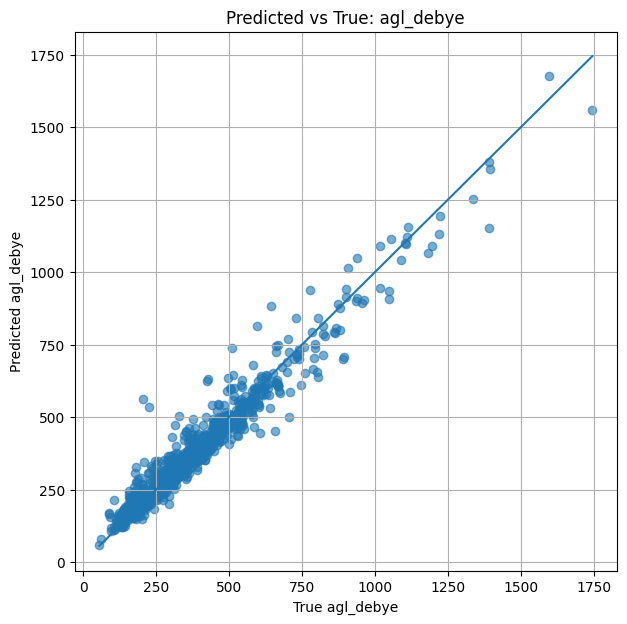


KERAS ENSEMBLE: agl_heat_capacity_Cv_300K
MSE: 4.3917
MAE: 0.7694
R² score: 0.9915
Превышение более чем на 15: 8 из 1131 (0.71%)
Mean relative error %: 3.3677461554554684
Median relative error %: 1.5882667001194526


,Состав,pred_heat_Cv,true_heat_Cv,diff,%_error
482,Cl8H24N8,75.0546,104.4370,-29.3824,28.1341
967,O8Pa4,32.1214,8.1790,23.9425,292.7328
790,K8Sn46,139.6436,160.7850,-21.1414,13.1489
524,Cs6Hg40,119.7328,137.9650,-18.2322,13.2151
428,Ca4N8O24,88.2401,71.6113,16.6288,23.2209


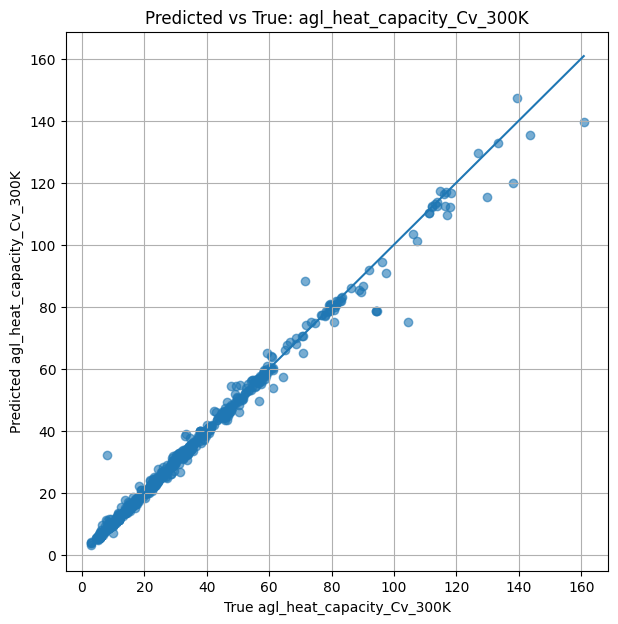


KERAS ENSEMBLE: agl_heat_capacity_Cp_300K
MSE: 5.3416
MAE: 0.8629
R² score: 0.9905
Превышение более чем на 15: 9 из 1131 (0.80%)
Mean relative error %: 3.5648454904121873
Median relative error %: 1.8015746942624773


,Состав,pred_heat_Cp,true_heat_Cp,diff,%_error
482,Cl8H24N8,79.0185,108.9470,-29.9285,27.4707
967,O8Pa4,32.3524,8.3270,24.0254,288.5232
469,Cl16Hg12O4,78.5558,101.1070,-22.5512,22.3043
468,Cl16Hg12O4,78.5584,101.0340,-22.4756,22.2456
467,Cl16Hg12O4,78.5561,100.8850,-22.3289,22.1330


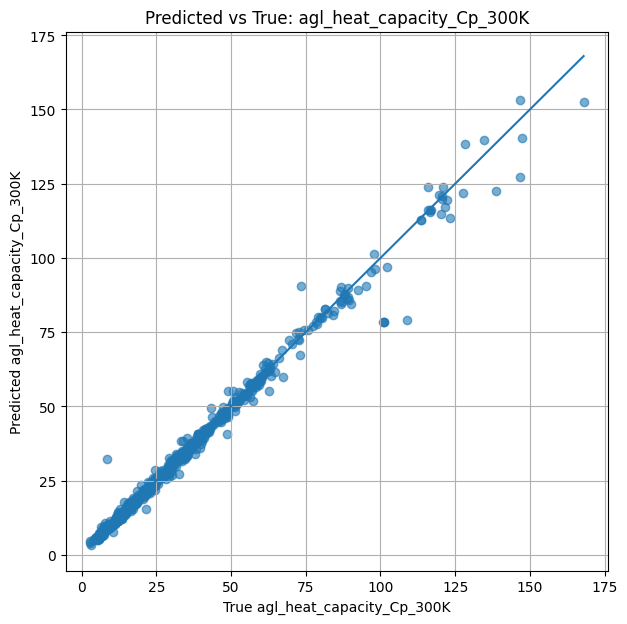


KERAS ENSEMBLE: agl_thermal_conductivity_300K
MSE: 16.8047
MAE: 1.8039
R² score: 0.8230
Превышение более чем на 15: 17 из 1131 (1.50%)
Mean relative error %: 34.408717279144916
Median relative error %: 18.429584644987315


,Состав,pred_thermal_conductivity,true_thermal_conductivity,diff,%_error
357,C1N2,81.4480,127.9680,-46.5200,36.3528
876,N1Nb1,37.8530,79.1840,-41.3310,52.1961
236,B2Sc1,53.8163,90.2972,-36.4809,40.4009
875,N1Nb1,33.4082,66.0028,-32.5946,49.3836
241,B2Y1,36.7222,63.2266,-26.5044,41.9198


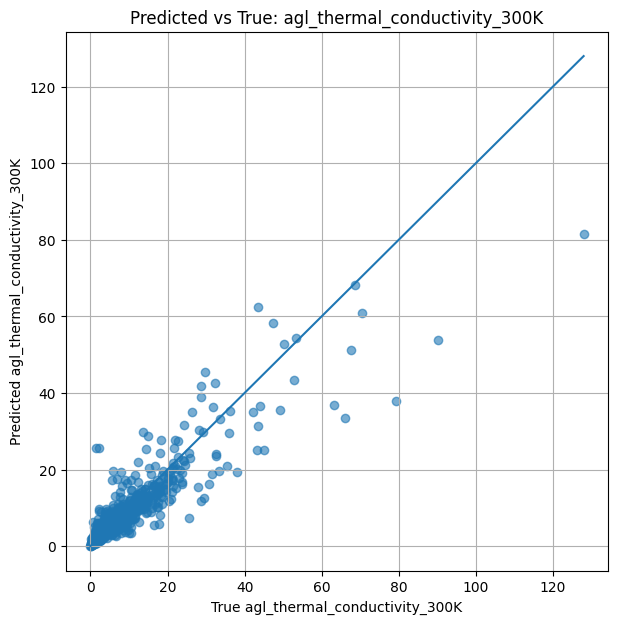


KERAS ENSEMBLE: agl_thermal_expansion_300K
MSE: 0.0000
MAE: 0.0000
R² score: 0.9050
Превышение более чем на 15: 0 из 1131 (0.00%)
Mean relative error %: 6.771997753727927
Median relative error %: 4.119650247647878


,Состав,pred_thermal_expansion,true_thermal_expansion,diff,%_error
491,Co2Se2Tl1,0.0001,0.0003,-0.0002,76.9704
698,H1K1,0.0003,0.0004,-0.0001,33.4200
290,Ba6Mn2N6,0.0001,0.0002,-0.0001,58.4383
523,Cs4I8Li4,0.0002,0.0003,-0.0001,35.8432
726,Hg6Yb2,0.0001,0.0002,-0.0001,34.7496


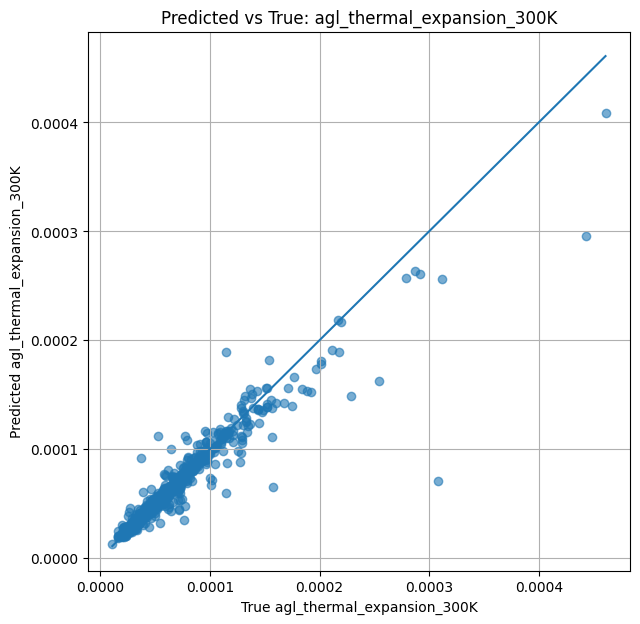


KERAS ENSEMBLE: agl_bulk_modulus_isothermal_300K
MSE: 62.5012
MAE: 4.3922
R² score: 0.9866
Превышение более чем на 15: 63 из 1131 (5.57%)
Mean relative error %: 5.051396890804042
Median relative error %: 2.6858547532337447


,Состав,pred_bulk_iso,true_bulk_iso,diff,%_error
865,Mo1P1,151.7742,77.1820,74.5922,96.6446
1024,Pt1V3,163.4926,94.1745,69.3181,73.6060
856,Mn1S1,113.2197,177.8670,-64.6473,36.3459
517,Cr4Ti2,130.9738,182.4520,-51.4782,28.2146
514,Cr4Hf2,130.3330,178.6330,-48.3000,27.0387


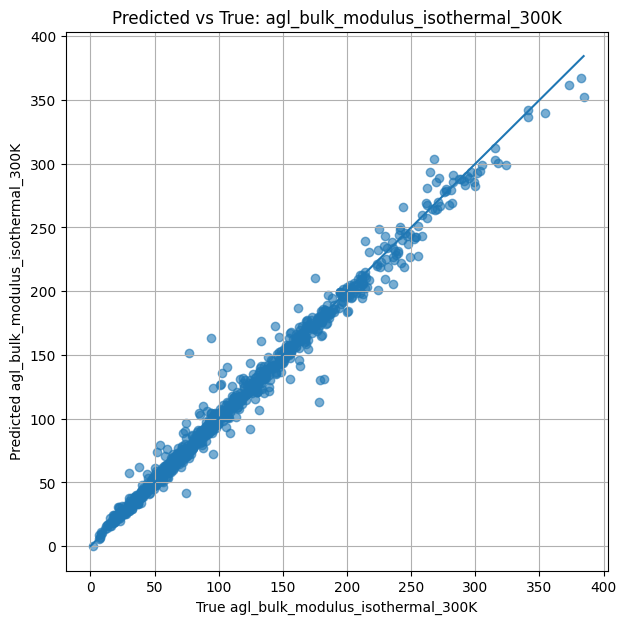


KERAS ENSEMBLE: agl_bulk_modulus_static_300K
MSE: 61.7481
MAE: 4.4204
R² score: 0.9869
Превышение более чем на 15: 63 из 1131 (5.57%)
Mean relative error %: 4.829432297764177
Median relative error %: 2.8129371882795664


,Состав,pred_bulk_static,true_bulk_static,diff,%_error
865,Mo1P1,153.5603,77.9564,75.6039,96.9823
1024,Pt1V3,166.2882,97.3046,68.9836,70.8945
856,Mn1S1,116.4336,182.3010,-65.8674,36.1311
517,Cr4Ti2,134.6654,185.1860,-50.5206,27.2810
514,Cr4Hf2,134.3252,181.1960,-46.8708,25.8675


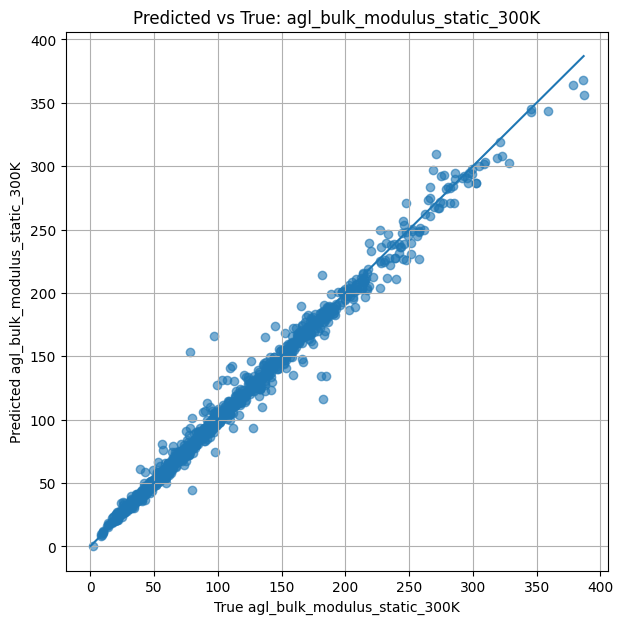


KERAS ENSEMBLE: agl_acoustic_debye
MSE: 735.0925
MAE: 16.6115
R² score: 0.9346
Превышение более чем на 15: 400 из 1131 (35.37%)
Mean relative error %: 9.228206413797082
Median relative error %: 6.390302110023594


,Состав,pred_acoustic_debye,true_acoustic_debye,diff,%_error
368,C1Ru1,422.7972,162.7090,260.0882,159.8487
369,C1Ru1,409.9031,179.3760,230.5271,128.5161
961,O4,524.6309,374.1970,150.4339,40.2018
896,N4,302.1864,443.4920,-141.3056,31.8620
357,C1N2,971.7475,1107.3000,-135.5525,12.2417


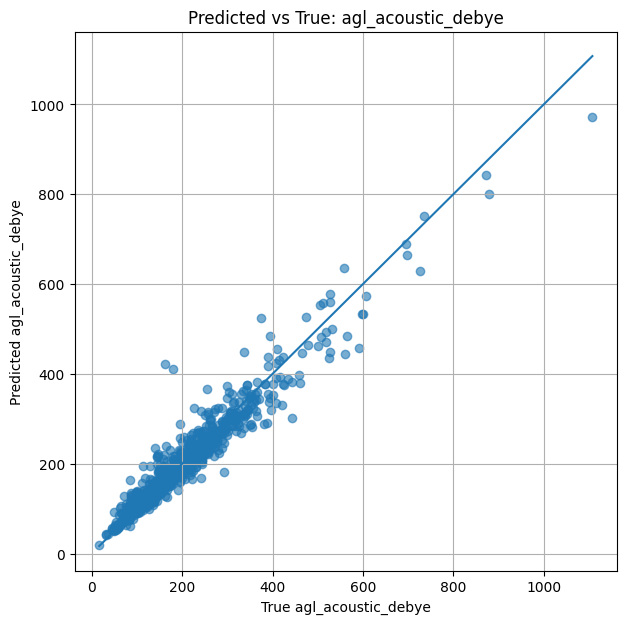


KERAS ENSEMBLE: agl_gruneisen
MSE: 0.0168
MAE: 0.0569
R² score: 0.7165
Превышение более чем на 15: 0 из 1131 (0.00%)
Mean relative error %: 2.779158794282093
Median relative error %: 1.3817431036121783


,Состав,pred_gruneisen,true_gruneisen,diff,%_error
290,Ba6Mn2N6,2.0652,3.8640,-1.7988,46.5536
554,Cu5Nd1,2.5113,1.1421,1.3691,119.8748
491,Co2Se2Tl1,2.2928,3.5121,-1.2193,34.7161
306,Be8V4,1.7130,2.8572,-1.1442,40.0462
494,Co4Ge4Ta4,2.0857,1.0832,1.0025,92.5551


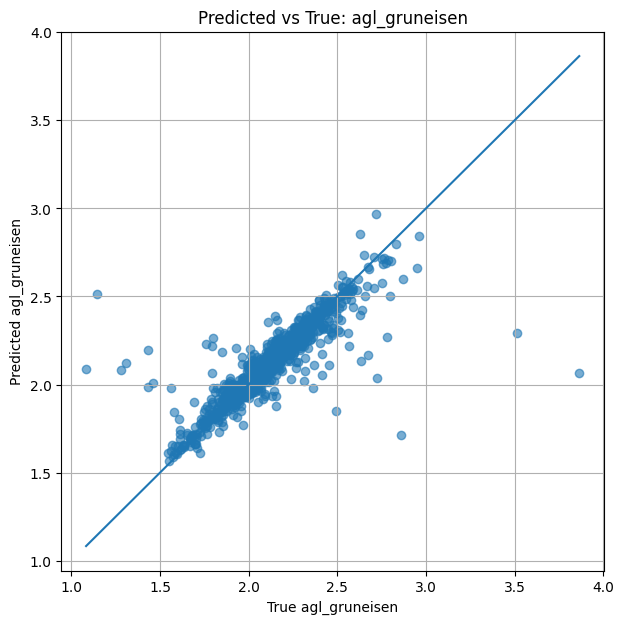

In [6]:
threshold = 15

#ensemble_pred = np.mean(preds, axis=0)
ensemble_pred = np.clip(ensemble_pred, 0, None)

if ensemble_pred.ndim == 1:
    ensemble_pred = ensemble_pred.reshape(-1, 1)

result_multi = pd.DataFrame({
    "compound": compound_val,
})

short_names = {
    "agl_debye": "debye",
    "agl_heat_capacity_Cv_300K": "heat_Cv",
    "agl_heat_capacity_Cp_300K": "heat_Cp",
    "agl_thermal_conductivity_300K": "thermal_conductivity",
    "agl_thermal_expansion_300K": "thermal_expansion",
    "agl_bulk_modulus_isothermal_300K": "bulk_iso",
    "agl_bulk_modulus_static_300K": "bulk_static",
    "agl_acoustic_debye": "acoustic_debye",
    "agl_gruneisen": "gruneisen",
}

target_tables = {}

for i, target in enumerate(target_cols):
    short = short_names.get(target, target.replace("agl_", ""))

    pred_col = f"pred_{target}"
    true_col = f"true_{target}"
    diff_col = f"diff_{target}"
    rel_col = f"rel_error_%_{target}"

    result_multi[pred_col] = ensemble_pred[:, i]
    result_multi[true_col] = y_val[target].values
    result_multi[diff_col] = result_multi[pred_col] - result_multi[true_col]

    abs_diff = result_multi[diff_col].abs()

    result_multi[rel_col] = (
        abs_diff / result_multi[true_col].abs()
    ) * 100

    count = (abs_diff > threshold).sum()

    true = result_multi[true_col]
    pred = result_multi[pred_col]

    mse = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)

    print(f"\nKERAS ENSEMBLE: {target}")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R² score: {r2:.4f}")
    print(f"Превышение более чем на {threshold}: {count} из {len(result_multi)} "
          f"({count / len(result_multi) * 100:.2f}%)")
    print("Mean relative error %:", result_multi[rel_col].mean())
    print("Median relative error %:", result_multi[rel_col].median())

    target_table = pd.DataFrame({
        "Состав": result_multi["compound"],
        f"pred_{short}": result_multi[pred_col],
        f"true_{short}": result_multi[true_col],
        "diff": result_multi[diff_col],
        "%_error": result_multi[rel_col],
    })

    target_tables[target] = target_table

    display(
        target_table.loc[abs_diff.sort_values(ascending=False).index].head(5)
    )

    plt.figure(figsize=(7, 7))
    plt.scatter(true, pred, alpha=0.6)

    min_val = min(true.min(), pred.min())
    max_val = max(true.max(), pred.max())

    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel(f"True {target}")
    plt.ylabel(f"Predicted {target}")
    plt.title(f"Predicted vs True: {target}")
    plt.grid(True)
    plt.show()

In [7]:
for i, target in enumerate(target_cols):
    print(target)
    print("R2:", r2_score(y_val[target].values, ensemble_pred[:, i]))
    print("MAE:", mean_absolute_error(y_val[target].values, ensemble_pred[:, i]))
    print()

agl_debye
R2: 0.9471174378960695
MAE: 29.8228486071268

agl_heat_capacity_Cv_300K
R2: 0.9915120174448264
MAE: 0.7693669064861275

agl_heat_capacity_Cp_300K
R2: 0.9905106049365341
MAE: 0.8629149883682045

agl_thermal_conductivity_300K
R2: 0.823030329773553
MAE: 1.8038618151698693

agl_thermal_expansion_300K
R2: 0.9050149656495307
MAE: 4.5484793769709245e-06

agl_bulk_modulus_isothermal_300K
R2: 0.986585500611827
MAE: 4.392176519406231

agl_bulk_modulus_static_300K
R2: 0.986945716983643
MAE: 4.420352840854946

agl_acoustic_debye
R2: 0.9345900475408752
MAE: 16.61151399106664

agl_gruneisen
R2: 0.7165197815061222
MAE: 0.05693640775567502



In [8]:
preds_arr = np.array(preds)

maes = np.array([s["mae"] for s in scores])

weights = 1.0 / (maes + 1e-9)
weights = weights / weights.sum()

weighted_ensemble_pred = np.sum(preds_arr * weights[:, None], axis=0)

mse = mean_squared_error(y_val, weighted_ensemble_pred)
mae = mean_absolute_error(y_val, weighted_ensemble_pred)
r2 = r2_score(y_val, weighted_ensemble_pred)

print("\nWEIGHTED KERAS ENSEMBLE")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² score: {r2:.4f}")

NameError: name 'preds' is not defined

In [ ]:
import re
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def get_elements(formula):
    return re.findall(r"([A-Z][a-z]?)", str(formula))

noble_gases = {"He", "Ne", "Ar", "Kr", "Xe", "Rn"}

result_check = pd.DataFrame({
    "compound": compound_val,
    "true": y_val.values,
    "pred": ensemble_pred,
})

result_check["diff"] = result_check["pred"] - result_check["true"]
result_check["abs_diff"] = result_check["diff"].abs()
result_check["elements"] = result_check["compound"].apply(get_elements)
result_check["n_elements"] = result_check["elements"].apply(lambda x: len(set(x)))
result_check["has_noble_gas"] = result_check["elements"].apply(
    lambda els: any(e in noble_gases for e in els)
)

# если Egap_type доступен
if "Egap_type" in df_fe.columns:
    result_check["Egap_type"] = df_fe.iloc[val_idx]["Egap_type"].astype(str).str.lower().values
else:
    result_check["Egap_type"] = "unknown"

# нормальные металлические сплавы:
# 2+ элемента, без благородных газов, metal по Egap_type
mask_good_alloy = (
    (result_check["n_elements"] >= 2) &
    (~result_check["has_noble_gas"]) &
    (result_check["Egap_type"].eq("metal"))
)

good = result_check[mask_good_alloy].copy()

print("Всего val:", len(result_check))
print("Нормальных metallic alloys:", len(good))

print("MSE:", mean_squared_error(good["true"], good["pred"]))
print("MAE:", mean_absolute_error(good["true"], good["pred"]))
print("R2:", r2_score(good["true"], good["pred"]))

good.head(20)